# 06. DAG Critique, Variable Roles, and Backdoor Paths

Notebook 05 used AI to brainstorm candidate DAGs from a project brief. This notebook asks a harder question: how do we critique those DAGs?

A DAG brainstorm is useful only if we can inspect variable roles, identify open backdoor paths, decide which pre-treatment variables belong in an adjustment set, and catch bad controls. AI can help draft the critique, but path logic and human domain review must discipline the output.


## Mathematical Core

The core graph question is whether conditioning on a set $Z$ makes treatment assignment as-good-as random within strata of $Z$:

$$
Y(a) \perp A \mid Z.
$$

For an adjusted mean contrast, the corresponding estimand is

$$
\tau = \sum_z \left[\mathbb{E}(Y \mid A=1, Z=z) - \mathbb{E}(Y \mid A=0, Z=z)\right] p(z).
$$

Variable roles matter because conditioning can help or harm. Confounders belong in $Z$, mediators change the estimand, and colliders can create spurious association. A graph critique should therefore name the role of each variable before recommending adjustment.


## Learning Goals

By the end of this notebook, you should be able to:

- classify variables as confounders, mediators, colliders, selection variables, measurement variables, guardrails, or context variables;
- explain what a backdoor path is;
- use graph code to list backdoor paths from treatment to outcome;
- evaluate whether an adjustment set blocks confounding paths;
- detect bad controls, including mediators, descendants of treatment, and colliders;
- simulate how adjustment choices change an estimate;
- use LLMs to draft DAG critiques while validating structure and auditing causal content;
- compare all available local models on structured DAG-critique reliability and quality.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup


In [26]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache
from typing import Literal

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

from notebooks._shared.display import smart_display


In [27]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 2600
TEMPERATURE = 0.0
SEED = 202

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]


In [28]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def has_package(module_name):
    """Carry out the has package step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

runtime_status = pd.DataFrame(
    [
        ('torch', torch.__version__),
        ('cuda available', torch.cuda.is_available()),
        ('cuda device count', torch.cuda.device_count()),
        ('graphviz python package', has_package('graphviz')),
        ('networkx installed', has_package('networkx')),
        ('accelerate installed', has_package('accelerate')),
        ('transformers installed', has_package('transformers')),
        ('torchvision installed', has_package('torchvision')),
    ],
    columns=['check', 'value'],
)

smart_display(runtime_status)


,check,value
0,torch,2.11.0+cu130
1,cuda available,True
2,cuda device count,1
3,graphviz python package,True
4,networkx installed,True
5,accelerate installed,True
6,transformers installed,True
7,torchvision installed,True


## 2. Variable Roles Are Estimand-Specific

A variable does not have one permanent role. The same variable can be a confounder for one question, a mediator for another, and a selection variable in a third.

The role depends on the treatment, outcome, time zero, target estimand, and measurement process.


| role | definition | usual adjustment implication |
|---|---|---|
| confounder | Pre-treatment cause of both treatment and outcome | adjust for if measured well |
| mediator | Post-treatment pathway from treatment to outcome | do not adjust for total effect |
| collider | Common effect of two variables on a path | conditioning can open a noncausal path |
| selection variable | Determines whether units enter the observed/analysis data | define population carefully; avoid post-treatment selection |
| instrument | Cause of treatment with no direct path to outcome except through treatment | use only under strong IV assumptions |
| proxy | Noisy measurement of another causal variable | use carefully; can leave residual confounding |
| measurement variable | Affects how an outcome or exposure is logged | represent explicitly when measurement changes |
| guardrail outcome | Secondary post-treatment outcome used to block launch | analyze as outcome, not adjustment variable |
| context variable | Background condition shaping mechanisms | may define strata or transportability limits |


## 3. Running Example: A DAG to Critique

The DAG represents an AI support-assistant rollout. The treatment is assistant enablement, the main outcome is human-handled workload, and the graph includes readiness, backlog, ticket mix, manager request, assistant usage, deflection, CSAT, reopen rate, and review selection. Some variables are pre-treatment causes, some are post-treatment mechanisms, and some are guardrails.

The experiment in this notebook is a graph-audit experiment. We start with a plausible but imperfect DAG and ask which paths create confounding, which variables should be left out of a total-effect adjustment set, and which variables belong in guardrail or mechanism analysis. The goal is to teach variable-role discipline before the LLM is allowed to recommend controls.


In [30]:
# Section focus: 3. Running Example: A DAG to Critique.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

NODE_ROLES = {
    'treatment', 'outcome', 'confounder', 'mediator', 'collider', 'selection',
    'instrument', 'guardrail', 'measurement', 'post_treatment', 'context', 'proxy', 'unknown',
}
EDGE_CONFIDENCE = {'low', 'medium', 'high'}

class DAGNode(BaseModel):
    node_id: str
    label: str
    role: Literal['treatment', 'outcome', 'confounder', 'mediator', 'collider', 'selection', 'instrument', 'guardrail', 'measurement', 'post_treatment', 'context', 'proxy', 'unknown']
    timing: str
    observed: bool | str
    description: str

class DAGEdge(BaseModel):
    source: str
    target: str
    rationale: str
    confidence: Literal['low', 'medium', 'high'] = 'medium'

class CandidateDAG(BaseModel):
    graph_id: str
    project_question: str
    treatment_node: str
    outcome_node: str
    nodes: list[DAGNode]
    edges: list[DAGEdge]
    proposed_adjustment_set: list[str] = Field(default_factory=list)


In [31]:
# Section focus: 3. Running Example: A DAG to Critique.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

node_records = [
    ('queue_volume', 'Baseline queue volume', 'confounder', 'pre-treatment', True, 'Historical incoming ticket volume before rollout.'),
    ('operational_readiness', 'Operational readiness', 'confounder', 'pre-treatment', True, 'Technical and managerial readiness for assistant rollout.'),
    ('staffing_level', 'Staffing level', 'confounder', 'pre-treatment', True, 'Number and experience of support agents.'),
    ('baseline_backlog', 'Baseline backlog', 'confounder', 'pre-treatment', True, 'Open ticket backlog before rollout.'),
    ('manager_request', 'Manager request', 'selection', 'pre-treatment', True, 'Managers asking for the assistant early.'),
    ('assistant_enabled', 'Assistant enabled', 'treatment', 'treatment', True, 'Assistant enabled for triage and first-draft responses.'),
    ('agent_adoption', 'Agent adoption', 'mediator', 'post-treatment', True, 'Agents actually using the assistant.'),
    ('ticket_deflection', 'Ticket deflection', 'mediator', 'post-treatment', True, 'Tickets handled before human intervention.'),
    ('deflection_logging', 'Deflection logging', 'measurement', 'post-treatment', True, 'Whether deflected tickets are logged consistently.'),
    ('human_handled_workload', 'Human-handled workload', 'outcome', 'post-treatment', True, 'Human-handled tickets per queue-day.'),
    ('reopen_rate', 'Reopen rate', 'guardrail', 'post-treatment', True, 'Resolved tickets reopened within 7 days.'),
    ('csat', 'Customer satisfaction', 'guardrail', 'post-treatment', True, 'Customer satisfaction after support interaction.'),
    ('executive_review', 'Executive review flag', 'collider', 'post-treatment', True, 'Flag for queues reviewed by leadership after rollout, driven by treatment visibility and workload concerns.'),
]

edge_records = [
    ('queue_volume', 'assistant_enabled', 'High-volume queues were prioritized.', 'high'),
    ('queue_volume', 'human_handled_workload', 'More incoming demand increases human workload.', 'high'),
    ('operational_readiness', 'assistant_enabled', 'Ready queues adopted earlier.', 'high'),
    ('operational_readiness', 'human_handled_workload', 'Readiness improves operations independent of the assistant.', 'medium'),
    ('staffing_level', 'assistant_enabled', 'Better-staffed queues can absorb rollout.', 'medium'),
    ('staffing_level', 'human_handled_workload', 'Staffing changes capacity and workload.', 'high'),
    ('baseline_backlog', 'assistant_enabled', 'Backlogged queues request help.', 'medium'),
    ('baseline_backlog', 'human_handled_workload', 'Backlog predicts future workload.', 'high'),
    ('manager_request', 'assistant_enabled', 'Manager request affects rollout timing.', 'high'),
    ('manager_request', 'human_handled_workload', 'Manager urgency may reflect unobserved workload pressure.', 'medium'),
    ('assistant_enabled', 'agent_adoption', 'Enablement makes adoption possible.', 'high'),
    ('assistant_enabled', 'ticket_deflection', 'Assistant can deflect tickets.', 'high'),
    ('assistant_enabled', 'deflection_logging', 'Assistant rollout can change logging definitions.', 'medium'),
    ('agent_adoption', 'human_handled_workload', 'Adoption mediates workload reduction.', 'high'),
    ('ticket_deflection', 'human_handled_workload', 'Deflection reduces measured human workload.', 'high'),
    ('deflection_logging', 'human_handled_workload', 'Logging changes measured workload.', 'medium'),
    ('assistant_enabled', 'reopen_rate', 'Assistant can affect quality.', 'medium'),
    ('assistant_enabled', 'csat', 'Assistant can affect satisfaction.', 'medium'),
    ('assistant_enabled', 'executive_review', 'Visible assistant rollout attracts leadership review.', 'medium'),
    ('human_handled_workload', 'executive_review', 'High workload also triggers leadership review.', 'high'),
]

candidate_dag = CandidateDAG.model_validate(
    {
        'graph_id': 'ai_support_dag_to_critique_v1',
        'project_question': 'What is the total causal effect of enabling the AI support assistant on human-handled ticket workload?',
        'treatment_node': 'assistant_enabled',
        'outcome_node': 'human_handled_workload',
        'nodes': [
            {'node_id': node_id, 'label': label, 'role': role, 'timing': timing, 'observed': observed, 'description': description}
            for node_id, label, role, timing, observed, description in node_records
        ],
        'edges': [
            {'source': source, 'target': target, 'rationale': rationale, 'confidence': confidence}
            for source, target, rationale, confidence in edge_records
        ],
        'proposed_adjustment_set': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request'],
    }
)

smart_display(candidate_dag)


CandidateDAG(graph_id='ai_support_dag_to_critique_v1', project_question='What is the total causal effect of enabling the AI support assistant on human-handled ticket workload?', treatment_node='assistant_enabled', outcome_node='human_handled_workload', nodes=[DAGNode(node_id='queue_volume', label='Baseline queue volume', role='confounder', timing='pre-treatment', observed=True, description='Historical incoming ticket volume before rollout.'), DAGNode(node_id='operational_readiness', label='Operational readiness', role='confounder', timing='pre-treatment', observed=True, description='Technical and managerial readiness for assistant rollout.'), DAGNode(node_id='staffing_level', label='Staffing level', role='confounder', timing='pre-treatment', observed=True, description='Number and experience of support agents.'), DAGNode(node_id='baseline_backlog', label='Baseline backlog', role='confounder', timing='pre-treatment', observed=True, description='Open ticket backlog before rollout.'), DAGN

In Running Example: A DAG to Critique, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


## 4. Render the DAG


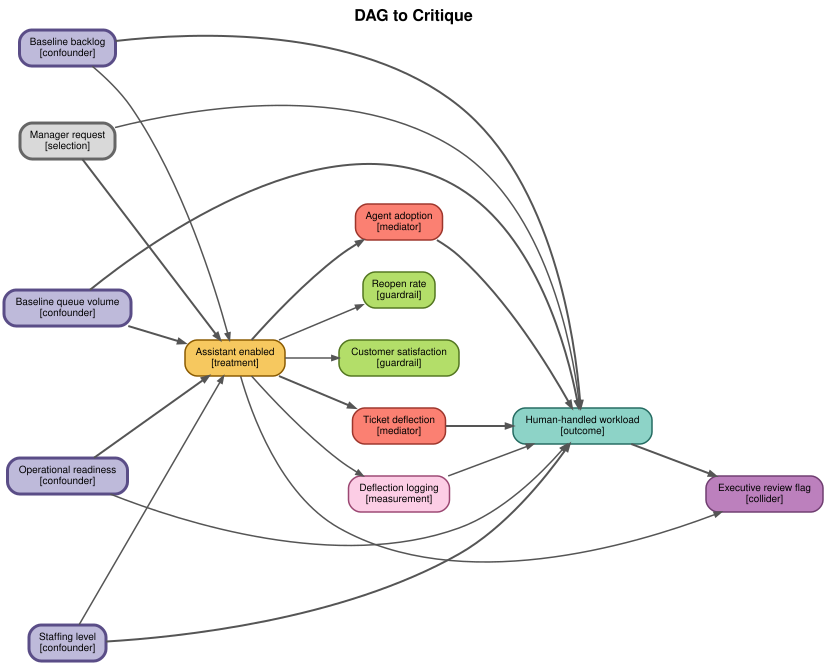

In [32]:
# Section focus: 4. Render the DAG.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

ROLE_STYLES = {
    'treatment': {'fillcolor': '#f6c85f', 'color': '#8a5a00'},
    'outcome': {'fillcolor': '#8dd3c7', 'color': '#246b61'},
    'confounder': {'fillcolor': '#bebada', 'color': '#5a4d87'},
    'mediator': {'fillcolor': '#fb8072', 'color': '#9d352b'},
    'collider': {'fillcolor': '#bc80bd', 'color': '#6f3d70'},
    'selection': {'fillcolor': '#d9d9d9', 'color': '#666666'},
    'measurement': {'fillcolor': '#fccde5', 'color': '#9b4772'},
    'guardrail': {'fillcolor': '#b3de69', 'color': '#52751f'},
    'proxy': {'fillcolor': '#ccebc5', 'color': '#4e7f47'},
    'unknown': {'fillcolor': '#eeeeee', 'color': '#777777'},
}


def short_label(text, width=22):
    """Carry out the short label step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    width : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the short label calculation and reused by later cells.
    """
    words = str(text).split()
    lines = []
    current = []
    for word in words:
        if sum(len(w) for w in current) + len(current) + len(word) > width and current:
            lines.append(' '.join(current))
            current = [word]
        else:
            current.append(word)
    if current:
        lines.append(' '.join(current))
    return '\n'.join(lines[:3])


def render_dag(dag, title=None, highlighted_nodes=None):
    """Render dag for display in the 06. DAG Critique, Variable Roles, and Backdoor Paths notebook.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    title : object
        Title used to label the displayed result.
    highlighted_nodes : object
        The highlighted nodes setting that controls the dag calculation in this notebook.
    
    Returns
    -------
    object
        Graph, figure, or visual specification produced by the dag workflow.
    """
    highlighted_nodes = set(highlighted_nodes or [])
    dot = Digraph(format='svg')
    dot.attr(rankdir='LR', bgcolor='white', splines='spline', overlap='false', nodesep='0.45', ranksep='0.75')
    dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica', fontsize='10', margin='0.08,0.06')
    dot.attr('edge', fontname='Helvetica', fontsize='8', color='#555555', arrowsize='0.7')
    if title:
        dot.attr(label=title, labelloc='t', fontsize='16', fontname='Helvetica-Bold')
    for node in dag.nodes:
        style = ROLE_STYLES.get(node.role, ROLE_STYLES['unknown'])
        penwidth = '3' if node.node_id in highlighted_nodes else '1.5'
        dot.node(node.node_id, label=f'{short_label(node.label)}\n[{node.role}]', fillcolor=style['fillcolor'], color=style['color'], penwidth=penwidth)
    for edge in dag.edges:
        dot.edge(edge.source, edge.target, penwidth={'low': '1.0', 'medium': '1.5', 'high': '2.0'}.get(edge.confidence, '1.2'))
    return dot

render_dag(candidate_dag, title='DAG to Critique', highlighted_nodes=candidate_dag.proposed_adjustment_set)


The graph is a design object. In Render the DAG, it tells us which variables are treated as causes, consequences, evidence, or decision outputs. Read the structure through the adjustment, diagnostic, or AI review it is supposed to support.


## 5. Backdoor Paths

A backdoor path from treatment $T$ to outcome $Y$ is any noncausal path that starts with an arrow into $T$.

For example:

$$
T \leftarrow X \rightarrow Y
$$

is a backdoor path because $X$ causes both treatment and outcome. If $X$ is observed and pre-treatment, adjusting for $X$ can block the path.

But not every variable on a path should be adjusted for. Conditioning on a mediator can block the causal effect. Conditioning on a collider can open a path that was otherwise closed.


In [33]:
# Section focus: 5. Backdoor Paths.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def to_networkx(dag):
    """Carry out the to networkx step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        Intermediate result produced by the to networkx calculation and reused by later cells.
    """
    graph = nx.DiGraph()
    for node in dag.nodes:
        graph.add_node(node.node_id, role=node.role, label=node.label, timing=node.timing)
    for edge in dag.edges:
        graph.add_edge(edge.source, edge.target, rationale=edge.rationale, confidence=edge.confidence)
    return graph


def is_collider_on_path(graph, previous_node, current_node, next_node):
    """Carry out the is collider on path step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    graph : object
        Graph object or graph specification used for structure and path analysis.
    previous_node : object
        The previous node setting that controls the is collider on path calculation in this notebook.
    current_node : object
        The current node setting that controls the is collider on path calculation in this notebook.
    next_node : object
        The next node setting that controls the is collider on path calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the is collider on path calculation and reused by later cells.
    """
    return graph.has_edge(previous_node, current_node) and graph.has_edge(next_node, current_node)


def descendants_in_set(graph, node, adjustment_set):
    """Carry out the descendants in set step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    graph : object
        Graph object or graph specification used for structure and path analysis.
    node : object
        The node setting that controls the descendants in set calculation in this notebook.
    adjustment_set : object
        The adjustment set setting that controls the descendants in set calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the descendants in set calculation and reused by later cells.
    """
    return bool(set(nx.descendants(graph, node)).intersection(adjustment_set))


def path_status(graph, path, adjustment_set):
    """Carry out the path status step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    graph : object
        Graph object or graph specification used for structure and path analysis.
    path : object
        Path-like value used to locate an input or output artifact.
    adjustment_set : object
        The adjustment set setting that controls the path status calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    adjustment_set = set(adjustment_set)
    blocked_by = []
    opened_by = []
    collider_notes = []

    for idx in range(1, len(path) - 1):
        previous_node, current_node, next_node = path[idx - 1], path[idx], path[idx + 1]
        is_collider = is_collider_on_path(graph, previous_node, current_node, next_node)
        if is_collider:
            if current_node in adjustment_set or descendants_in_set(graph, current_node, adjustment_set):
                opened_by.append(current_node)
                collider_notes.append(f'collider {current_node} conditioned on or descendant conditioned on')
            else:
                blocked_by.append(current_node)
                collider_notes.append(f'collider {current_node} blocks path')
        else:
            if current_node in adjustment_set:
                blocked_by.append(current_node)

    is_open = len(blocked_by) == 0
    return {
        'is_open': is_open,
        'blocked_by': ', '.join(blocked_by),
        'opened_by': ', '.join(opened_by),
        'collider_notes': '; '.join(collider_notes),
    }


def backdoor_paths(graph, treatment, outcome, cutoff=6):
    """Carry out the backdoor paths step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    graph : object
        Graph object or graph specification used for structure and path analysis.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    
    Returns
    -------
    object
        Intermediate result produced by the backdoor paths calculation and reused by later cells.
    """
    undirected = graph.to_undirected()
    paths = []
    for path in nx.all_simple_paths(undirected, source=treatment, target=outcome, cutoff=cutoff):
        if len(path) < 2:
            continue
        first_neighbor = path[1]
        if graph.has_edge(first_neighbor, treatment):
            paths.append(path)
    return paths


def backdoor_path_table(dag, adjustment_set=None, cutoff=6):
    """Carry out the backdoor path table step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    adjustment_set : object
        The adjustment set setting that controls the backdoor path table calculation in this notebook.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    graph = to_networkx(dag)
    adjustment_set = set(adjustment_set or [])
    rows = []
    for path in backdoor_paths(graph, dag.treatment_node, dag.outcome_node, cutoff=cutoff):
        status = path_status(graph, path, adjustment_set)
        rows.append(
            {
                'path': ' -> '.join(path),
                'open_after_adjustment': status['is_open'],
                'blocked_by': status['blocked_by'],
                'opened_by': status['opened_by'],
                'collider_notes': status['collider_notes'],
            }
        )
    return pd.DataFrame(rows)

candidate_graph = to_networkx(candidate_dag)
print('Is DAG acyclic?', nx.is_directed_acyclic_graph(candidate_graph))
print('Number of backdoor paths:', len(backdoor_paths(candidate_graph, candidate_dag.treatment_node, candidate_dag.outcome_node)))


Is DAG acyclic? True
Number of backdoor paths: 5


This diagram makes the assumed structure visible. For Backdoor Paths, the arrows are commitments about what can influence what, and in which order. The value of the graph is that it turns hidden modeling judgment into something the analyst can critique, revise, and explain to a stakeholder.


In [34]:
backdoor_path_table(candidate_dag, adjustment_set=[])


,path,open_after_adjustment,blocked_by,opened_by,collider_notes
0,assistant_enabled -> queue_volume -> human_handled_workload,True,,,
1,assistant_enabled -> operational_readiness -> human_handled_workload,True,,,
2,assistant_enabled -> staffing_level -> human_handled_workload,True,,,
3,assistant_enabled -> baseline_backlog -> human_handled_workload,True,,,
4,assistant_enabled -> manager_request -> human_handled_workload,True,,,


This diagram makes the assumed structure visible. For Backdoor Paths, the arrows are commitments about what can influence what, and in which order. The value of the graph is that it turns hidden modeling judgment into something the analyst can critique, revise, and explain to a stakeholder.


## 6. Comparing Adjustment Sets


In [35]:
adjustment_sets = {
    'none': [],
    'pre_treatment_confounders': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request'],
    'bad_controls_with_mediators': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request', 'agent_adoption', 'ticket_deflection'],
    'collider_adjustment': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request', 'executive_review'],
}

adjustment_summary = []
for name, adjustment_set in adjustment_sets.items():
    table = backdoor_path_table(candidate_dag, adjustment_set=adjustment_set)
    open_paths = int(table['open_after_adjustment'].sum()) if not table.empty else 0
    adjustment_summary.append({'adjustment_set': name, 'variables': ', '.join(adjustment_set) or 'none', 'open_backdoor_paths': open_paths, 'total_backdoor_paths': len(table)})

pd.DataFrame(adjustment_summary)


,adjustment_set,variables,open_backdoor_paths,total_backdoor_paths
0,none,none,5,5
1,pre_treatment_confounders,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request",0,5
2,bad_controls_with_mediators,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request, agent_adoption, ticket_deflection",0,5
3,collider_adjustment,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request, executive_review",0,5


In Comparing Adjustment Sets, a polished answer is secondary. The design has to remain checkable.


In [36]:
backdoor_path_table(candidate_dag, adjustment_set=adjustment_sets['pre_treatment_confounders'])


,path,open_after_adjustment,blocked_by,opened_by,collider_notes
0,assistant_enabled -> queue_volume -> human_handled_workload,False,queue_volume,,
1,assistant_enabled -> operational_readiness -> human_handled_workload,False,operational_readiness,,
2,assistant_enabled -> staffing_level -> human_handled_workload,False,staffing_level,,
3,assistant_enabled -> baseline_backlog -> human_handled_workload,False,baseline_backlog,,
4,assistant_enabled -> manager_request -> human_handled_workload,False,manager_request,,


The pre-treatment adjustment set blocks the common-cause paths into treatment. It does not adjust for adoption, deflection, reopen rate, or CSAT because those are downstream of treatment.

The bad-control set includes mediators. It may block backdoor paths, but it also changes the estimand by blocking causal pathways from assistant enablement to workload.

The collider-adjustment set includes `executive_review`, a post-treatment common effect of treatment visibility and workload concerns. Conditioning on it can open noncausal dependence.


## 7. Role and Adjustment Audit


In [37]:
# Section focus: 7. Role and Adjustment Audit.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def role_adjustment_audit(dag, adjustment_set):
    """Carry out the role adjustment audit step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    adjustment_set : object
        The adjustment set setting that controls the role adjustment audit calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    roles = {node.node_id: node.role for node in dag.nodes}
    timing = {node.node_id: node.timing for node in dag.nodes}
    rows = []
    for variable in adjustment_set:
        role = roles.get(variable, 'missing')
        time = timing.get(variable, 'missing')
        issue = 'none flagged'
        if role in {'mediator', 'measurement', 'guardrail', 'post_treatment', 'outcome', 'treatment'}:
            issue = f'{role} is not a routine adjustment variable for a total-effect estimand'
        elif role == 'collider':
            issue = 'conditioning on a collider can open biasing paths'
        elif variable not in roles:
            issue = 'variable not found in DAG'
        elif 'post' in str(time).lower():
            issue = 'post-treatment timing needs review before adjustment'
        rows.append({'variable': variable, 'role': role, 'timing': time, 'issue': issue})
    return pd.DataFrame(rows)

role_adjustment_audit(candidate_dag, adjustment_sets['bad_controls_with_mediators'])


,variable,role,timing,issue
0,queue_volume,confounder,pre-treatment,none flagged
1,operational_readiness,confounder,pre-treatment,none flagged
2,staffing_level,confounder,pre-treatment,none flagged
3,baseline_backlog,confounder,pre-treatment,none flagged
4,manager_request,selection,pre-treatment,none flagged
5,agent_adoption,mediator,post-treatment,mediator is not a routine adjustment variable for a total-effect estimand
6,ticket_deflection,mediator,post-treatment,mediator is not a routine adjustment variable for a total-effect estimand


This diagram makes the assumed structure visible. For Role and Adjustment Audit, the arrows are commitments about what can influence what, and in which order. The value of the graph is that it turns hidden modeling judgment into something the analyst can critique, revise, and explain to a stakeholder.


## 8. Code Example: Adjustment Choices Change the Estimand


In [38]:
# Section focus: 8. Code Example: Adjustment Choices Change the Estimand.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))

rng = np.random.default_rng(SEED)
n = 22000

queue_volume = rng.normal(0, 1, n)
operational_readiness = rng.normal(0, 1, n)
staffing_level = rng.normal(0, 1, n)
baseline_backlog = 0.55 * queue_volume - 0.35 * staffing_level + rng.normal(0, 0.8, n)
manager_request = 0.55 * queue_volume + 0.4 * baseline_backlog + rng.normal(0, 0.7, n)

propensity = sigmoid(-0.2 + 0.7 * queue_volume + 0.8 * operational_readiness + 0.25 * staffing_level + 0.3 * baseline_backlog + 0.45 * manager_request)
assistant_enabled = rng.binomial(1, propensity)

agent_adoption = 0.8 * assistant_enabled + 0.35 * operational_readiness + rng.normal(0, 0.7, n)
ticket_deflection = 0.55 * assistant_enabled + 0.5 * agent_adoption + 0.2 * queue_volume + rng.normal(0, 0.8, n)

true_direct_effect = -0.45
true_total_effect = true_direct_effect - 0.25 * 0.8 - 0.35 * (0.55 + 0.5 * 0.8)

human_handled_workload = (
    3.0
    + true_direct_effect * assistant_enabled
    + 0.9 * queue_volume
    - 0.25 * operational_readiness
    - 0.45 * staffing_level
    + 0.55 * baseline_backlog
    + 0.35 * manager_request
    - 0.25 * agent_adoption
    - 0.35 * ticket_deflection
    + rng.normal(0, 1.0, n)
)

executive_review = rng.binomial(1, sigmoid(-1.0 + 0.9 * assistant_enabled + 0.55 * human_handled_workload), n)

sim_df = pd.DataFrame(
    {
        'queue_volume': queue_volume,
        'operational_readiness': operational_readiness,
        'staffing_level': staffing_level,
        'baseline_backlog': baseline_backlog,
        'manager_request': manager_request,
        'assistant_enabled': assistant_enabled,
        'agent_adoption': agent_adoption,
        'ticket_deflection': ticket_deflection,
        'human_handled_workload': human_handled_workload,
        'executive_review': executive_review,
        'propensity': propensity,
    }
)

sim_df.head()


,queue_volume,operational_readiness,staffing_level,baseline_backlog,manager_request,assistant_enabled,agent_adoption,ticket_deflection,human_handled_workload,executive_review,propensity
0,1.812,0.438,-0.966,1.207,0.981,1,0.842,1.703,3.089,1,0.879
1,-0.729,0.865,0.795,-2.340,-1.826,1,0.926,-0.207,-1.329,0,0.207
2,-1.086,0.300,0.829,-1.306,-1.631,0,0.864,1.128,-1.026,0,0.163
3,-0.402,-0.027,2.244,-1.926,-0.785,1,0.808,0.386,-0.547,0,0.295
4,-1.153,0.591,0.481,-1.455,-0.903,1,0.983,2.040,-0.411,0,0.221


Code Example: Adjustment Choices Change the Estimand should leave a clear trail from the business question to the causal assumptions and diagnostics.


In [39]:
# Section focus: 8. Code Example: Adjustment Choices Change the Estimand.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def ols_treatment_coefficient(df, outcome, treatment, covariates):
    """Carry out the ols treatment coefficient step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    columns = [treatment] + covariates
    x = df[columns].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(df)), x])
    y = df[outcome].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    residuals = y - x @ beta
    dof = len(y) - x.shape[1]
    sigma2 = residuals.T @ residuals / dof
    cov_beta = sigma2 * np.linalg.inv(x.T @ x)
    se = np.sqrt(np.diag(cov_beta))
    treatment_idx = columns.index(treatment) + 1
    return beta[treatment_idx], se[treatment_idx]

simulation_models = [
    ('Naive', []),
    ('Backdoor adjustment', ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request']),
    ('Bad controls: mediators', ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request', 'agent_adoption', 'ticket_deflection']),
    ('Collider adjustment', ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request', 'executive_review']),
]

rows = []
for label, covariates in simulation_models:
    estimate, se = ols_treatment_coefficient(sim_df, 'human_handled_workload', 'assistant_enabled', covariates)
    rows.append({'model': label, 'estimate': estimate, 'std_error': se, 'covariates': ', '.join(covariates) if covariates else 'none'})

simulation_results = pd.DataFrame(rows)
simulation_results['true_total_effect'] = true_total_effect
simulation_results['true_direct_effect'] = true_direct_effect
simulation_results['bias_vs_total'] = simulation_results['estimate'] - true_total_effect
smart_display(simulation_results)


,model,estimate,std_error,covariates,true_total_effect,true_direct_effect,bias_vs_total
0,Naive,0.155,0.026,none,-0.983,-0.450,1.137
1,Backdoor adjustment,-0.987,0.017,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request",-0.983,-0.450,-0.005
2,Bad controls: mediators,-0.463,0.018,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request, agent_adoption, ticket_deflection",-0.983,-0.450,0.519
3,Collider adjustment,-1.026,0.017,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request, executive_review",-0.983,-0.450,-0.043


In Code Example: Adjustment Choices Change the Estimand, the response is useful only if a human analyst can check it. Look for a clean causal structure, named assumptions, and any unsupported additions.


/tmp/ipykernel_3400694/2502223174.py:2: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=simulation_results, y='model', x='estimate', join=False, color='#4776A6')


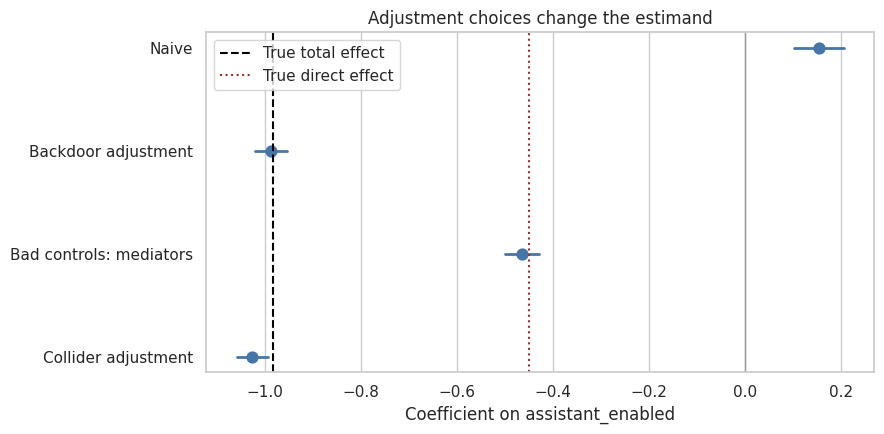

In [40]:
plt.figure(figsize=(9, 4.5))
sns.pointplot(data=simulation_results, y='model', x='estimate', join=False, color='#4776A6')
for idx, row in simulation_results.iterrows():
    plt.plot([row['estimate'] - 1.96 * row['std_error'], row['estimate'] + 1.96 * row['std_error']], [idx, idx], color='#4776A6', linewidth=2)
plt.axvline(true_total_effect, color='black', linestyle='--', label='True total effect')
plt.axvline(true_direct_effect, color='#993333', linestyle=':', label='True direct effect')
plt.axvline(0, color='#999999', linewidth=1)
plt.xlabel('Coefficient on assistant_enabled')
plt.ylabel('')
plt.title('Adjustment choices change the estimand')
plt.legend()
plt.tight_layout()
plt.show()


The backdoor adjustment model targets the total effect by blocking pre-treatment common causes of rollout and workload.

The mediator-adjusted model moves toward the direct effect because it controls for post-treatment mechanisms. That can be appropriate, but it answers a different question.

The collider-adjusted model conditions on a post-treatment review flag caused by treatment visibility and workload. That is a red flag: it can induce bias even when the pre-treatment confounders are included.


## 9. AI-Assisted DAG Critique


In [41]:
# Section focus: 9. AI-Assisted DAG Critique.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

class VariableRoleReview(BaseModel):
    node_id: str
    recommended_role: Literal['treatment', 'outcome', 'confounder', 'mediator', 'collider', 'selection', 'instrument', 'guardrail', 'measurement', 'post_treatment', 'context', 'proxy', 'unknown']
    adjust_for_total_effect: bool
    rationale: str
    confidence: Literal['low', 'medium', 'high'] = 'medium'

class PathReview(BaseModel):
    path: list[str]
    path_type: str
    status_after_recommended_adjustment: Literal['open', 'blocked', 'opened_by_adjustment', 'not_applicable']
    rationale: str

class DAGCritique(BaseModel):
    critique_id: str
    graph_id: str
    treatment_node: str
    outcome_node: str
    recommended_adjustment_set: list[str]
    forbidden_controls: list[str]
    variable_reviews: list[VariableRoleReview]
    backdoor_path_reviews: list[PathReview]
    warnings: list[str]
    domain_questions: list[str]
    final_assessment: str


In [42]:
# Section focus: 9. AI-Assisted DAG Critique.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

from pathlib import Path
import sys


def find_project_root(start=None):
    """Carry out the find project root step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    """Carry out the load local model step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the load local model workflow.
    """
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    """Carry out the decode generated text step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    tokenizer : object
        Tokenizer paired with the local language model for prompt encoding and decoding.
    generated : object
        Rate or probability parameter controlling this calculation.
    prompt_token_count : object
        Prompt text sent to the local language model in the live experiment.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the decode generated text workflow.
    """
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local generate step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local generate calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [43]:
# Section focus: 9. AI-Assisted DAG Critique.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_CRITIQUE_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant.
    Critique DAGs for variable roles, backdoor paths, and adjustment-set mistakes.
    Do not estimate the treatment effect. Return valid JSON only when asked for JSON.
    '''
).strip()

CRITIQUE_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Critique this DAG for estimating the total effect of treatment on outcome.

    DAG JSON:
    {dag_json}

    Proposed adjustment set:
    {adjustment_set}

    Return valid JSON only with exactly these keys:
    critique_id, graph_id, treatment_node, outcome_node, recommended_adjustment_set,
    forbidden_controls, variable_reviews, backdoor_path_reviews, warnings, domain_questions, final_assessment.

    variable_reviews must be an array of objects with keys:
    node_id, recommended_role, adjust_for_total_effect, rationale, confidence.

    recommended_role must be one of:
    treatment, outcome, confounder, mediator, collider, selection, instrument, guardrail,
    measurement, post_treatment, context, proxy, unknown.

    backdoor_path_reviews must be an array of objects with keys:
    path, path_type, status_after_recommended_adjustment, rationale.

    status_after_recommended_adjustment must be one of:
    open, blocked, opened_by_adjustment, not_applicable.

    Include warnings for mediators, guardrails, measurement variables, or colliders that should not be adjusted for in a total-effect analysis.

    Keep the JSON compact:
    - variable_reviews: exactly 8 objects, prioritizing the proposed controls plus agent_adoption, ticket_deflection, and executive_review.
    - backdoor_path_reviews: exactly 5 objects, one for each pre-treatment backdoor path.
    - warnings: 3 to 5 short strings.
    - domain_questions: 2 to 3 short strings.
    - rationales and final_assessment: one concise sentence each.
    Do not include markdown fences, prose before JSON, or prose after JSON.
    '''
).strip()

FALLBACK_CRITIQUE_JSON = json.dumps(
    {
        'critique_id': 'ai_support_dag_critique_v1',
        'graph_id': candidate_dag.graph_id,
        'treatment_node': candidate_dag.treatment_node,
        'outcome_node': candidate_dag.outcome_node,
        'recommended_adjustment_set': ['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request'],
        'forbidden_controls': ['agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat', 'executive_review'],
        'variable_reviews': [
            {'node_id': 'queue_volume', 'recommended_role': 'confounder', 'adjust_for_total_effect': True, 'rationale': 'Pre-treatment cause of rollout and workload.', 'confidence': 'high'},
            {'node_id': 'operational_readiness', 'recommended_role': 'confounder', 'adjust_for_total_effect': True, 'rationale': 'Affects rollout readiness and workload operations.', 'confidence': 'high'},
            {'node_id': 'agent_adoption', 'recommended_role': 'mediator', 'adjust_for_total_effect': False, 'rationale': 'Post-treatment mechanism from enablement to workload.', 'confidence': 'high'},
            {'node_id': 'ticket_deflection', 'recommended_role': 'mediator', 'adjust_for_total_effect': False, 'rationale': 'Post-treatment pathway from assistant to measured workload.', 'confidence': 'high'},
            {'node_id': 'executive_review', 'recommended_role': 'collider', 'adjust_for_total_effect': False, 'rationale': 'Post-treatment common effect of assistant visibility and workload concerns.', 'confidence': 'medium'},
        ],
        'backdoor_path_reviews': [
            {'path': ['assistant_enabled', 'queue_volume', 'human_handled_workload'], 'path_type': 'backdoor', 'status_after_recommended_adjustment': 'blocked', 'rationale': 'Blocked by queue_volume.'},
            {'path': ['assistant_enabled', 'operational_readiness', 'human_handled_workload'], 'path_type': 'backdoor', 'status_after_recommended_adjustment': 'blocked', 'rationale': 'Blocked by operational_readiness.'},
        ],
        'warnings': [
            'Do not adjust for agent_adoption or ticket_deflection when estimating the total effect.',
            'Do not condition on executive_review because it is a post-treatment collider.',
            'Guardrails should be analyzed as outcomes, not adjustment variables.',
        ],
        'domain_questions': [
            'Is manager_request a sufficient proxy for unobserved manager urgency?',
            'Were logging definitions changed at the same time as rollout?',
        ],
        'final_assessment': 'The proposed pre-treatment adjustment set is plausible, but post-treatment mediators, measurement variables, guardrails, and executive review should be excluded for the total-effect estimand.',
    },
    indent=2,
)


def critique_prompt(dag=candidate_dag):
    """Carry out the critique prompt step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the critique prompt workflow.
    """
    return CRITIQUE_PROMPT_TEMPLATE.format(
        dag_json=json.dumps(dag.model_dump(), indent=2),
        adjustment_set=', '.join(dag.proposed_adjustment_set),
    )


def dag_critique_llm(model_id=MODEL_ID):
    """Carry out the dag critique llm step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Graph, figure, or visual specification produced by the dag critique llm workflow.
    """
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(critique_prompt(), system_message=SYSTEM_CRITIQUE_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
    return FALLBACK_CRITIQUE_JSON

raw_dag_critique = dag_critique_llm()
print(raw_dag_critique[:1600])


{
 "critique_id": "001",
 "graph_id": "ai_support_dag_to_critique_v1",
 "treatment_node": "assistant_enabled",
 "outcome_node": "human_handled_workload",
 "recommended_adjustment_set": [
 "queue_volume",
 "operational_readiness",
 "staffing_level",
 "baseline_backlog",
 "manager_request"
 ],
 "forbidden_controls": [],
 "variable_reviews": [
 {
 "node_id": "assistant_enabled",
 "recommended_role": "treatment",
 "adjust_for_total_effect": false,
 "rationale": "This is the treatment variable.",
 "confidence": "high"
 },
 {
 "node_id": "human_handled_workload",
 "recommended_role": "outcome",
 "adjust_for_total_effect": false,
 "rationale": "This is the outcome variable.",
 "confidence": "high"
 },
 {
 "node_id": "queue_volume",
 "recommended_role": "confounder",
 "adjust_for_total_effect": true,
 "rationale": "Pre-treatment volume influences both treatment and outcome.",
 "confidence": "high"
 },
 {
 "node_id": "operational_readiness",
 "recommended_role": "confounder",
 "adjust_for_total

In AI-Assisted DAG Critique, the model earns trust by staying bounded by the evidence and by making uncertainty visible. A weak answer tells us which guardrail needs work.


## 10. Parsing and Auditing AI Critiques


In [44]:
# Section focus: 10. Parsing and Auditing AI Critiques.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

ROLE_MAP = {'cause': 'confounder', 'common cause': 'confounder', 'bad control': 'post_treatment', 'guardrail outcome': 'guardrail', 'exposure': 'treatment'}
STATUS_VALUES = {'open', 'blocked', 'opened_by_adjustment', 'not_applicable'}


def extract_json_object(text):
    """Extract the first JSON object from a model response for structured validation.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the json object workflow.
    """
    cleaned = clean_generated_text(text)
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned.strip())
    start = cleaned.find('{')
    end = cleaned.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    return cleaned[start : end + 1]


def node_id_from_text(value):
    """Carry out the node id from text step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the node id from text workflow.
    """
    value = clean_generated_text(value)
    value = re.sub(r'[^a-zA-Z0-9_]+', '_', value.strip().lower())
    return re.sub(r'_+', '_', value).strip('_') or 'unknown_node'


def normalize_role(value):
    """Carry out the normalize role step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    role = clean_generated_text(value).strip().lower().replace('-', '_').replace(' ', '_')
    readable = role.replace('_', ' ')
    if role in NODE_ROLES:
        return role, []
    if readable in ROLE_MAP:
        return ROLE_MAP[readable], [f'normalized role {value!r} to {ROLE_MAP[readable]!r}']
    if 'confound' in role:
        return 'confounder', [f'normalized role {value!r} to confounder']
    if 'mediator' in role:
        return 'mediator', [f'normalized role {value!r} to mediator']
    if 'collider' in role:
        return 'collider', [f'normalized role {value!r} to collider']
    if 'guard' in role:
        return 'guardrail', [f'normalized role {value!r} to guardrail']
    if 'measure' in role:
        return 'measurement', [f'normalized role {value!r} to measurement']
    if 'outcome' in role:
        return 'outcome', [f'normalized role {value!r} to outcome']
    if 'treat' in role or 'exposure' in role:
        return 'treatment', [f'normalized role {value!r} to treatment']
    return 'unknown', [f'normalized unknown role {value!r} to unknown']


def normalize_confidence(value):
    """Carry out the normalize confidence step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    confidence = clean_generated_text(value).strip().lower()
    if confidence in EDGE_CONFIDENCE:
        return confidence, []
    if confidence in {'certain', 'strong'}:
        return 'high', [f'normalized confidence {value!r} to high']
    if confidence in {'uncertain', 'weak'}:
        return 'low', [f'normalized confidence {value!r} to low']
    return 'medium', [f'normalized confidence {value!r} to medium']


def normalize_status(value):
    """Carry out the normalize status step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    status = clean_generated_text(value).strip().lower().replace('-', '_').replace(' ', '_')
    if status in STATUS_VALUES:
        return status, []
    if 'block' in status:
        return 'blocked', [f'normalized path status {value!r} to blocked']
    if 'open' in status and 'adjust' in status:
        return 'opened_by_adjustment', [f'normalized path status {value!r} to opened_by_adjustment']
    if 'open' in status:
        return 'open', [f'normalized path status {value!r} to open']
    return 'not_applicable', [f'normalized path status {value!r} to not_applicable']


def coerce_string_list(value):
    """Carry out the coerce string list step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    if value is None:
        return []
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        items = re.split(r';|\n', value) if (';' in value or '\n' in value) else [value]
    else:
        items = [value]
    out = []
    for item in items:
        if isinstance(item, dict):
            out.append(item.get('node_id') or item.get('name') or item.get('label') or item.get('path') or json.dumps(item))
        else:
            out.append(clean_generated_text(item))
    return [item for item in out if item]


def normalize_variable_reviews(value):
    """Carry out the normalize variable reviews step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if isinstance(value, dict):
        value = [{'node_id': key, **(val if isinstance(val, dict) else {'rationale': val})} for key, val in value.items()]
        notes.append('coerced variable_reviews from object to list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid variable_reviews to empty list')
    reviews = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            item = {'node_id': item, 'recommended_role': 'unknown', 'adjust_for_total_effect': False, 'rationale': item, 'confidence': 'medium'}
            notes.append(f'coerced variable_reviews[{idx}] from string to object')
        item = dict(item)
        item.setdefault('node_id', item.get('variable') or item.get('name') or f'node_{idx}')
        item['node_id'] = node_id_from_text(item['node_id'])
        item.setdefault('recommended_role', item.get('role') or 'unknown')
        role, role_notes = normalize_role(item['recommended_role'])
        item['recommended_role'] = role
        notes.extend(f'variable_reviews[{idx}]: {note}' for note in role_notes)
        item.setdefault('adjust_for_total_effect', role == 'confounder')
        if isinstance(item['adjust_for_total_effect'], str):
            item['adjust_for_total_effect'] = item['adjust_for_total_effect'].lower() in {'true', 'yes', 'adjust', 'include'}
        item.setdefault('rationale', item.get('reason') or 'role review')
        item['rationale'] = clean_generated_text(item['rationale'])
        item.setdefault('confidence', 'medium')
        confidence, confidence_notes = normalize_confidence(item['confidence'])
        item['confidence'] = confidence
        notes.extend(f'variable_reviews[{idx}]: {note}' for note in confidence_notes)
        reviews.append(item)
    return reviews, notes


def normalize_path_reviews(value):
    """Carry out the normalize path reviews step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if not isinstance(value, list):
        value = [] if value is None else [value]
        notes.append('coerced backdoor_path_reviews to list')
    reviews = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            path_nodes = [node_id_from_text(part) for part in re.split(r'->|→', item)]
            item = {'path': path_nodes, 'path_type': 'backdoor', 'status_after_recommended_adjustment': 'not_applicable', 'rationale': item}
            notes.append(f'coerced backdoor_path_reviews[{idx}] from string to object')
        item = dict(item)
        item.setdefault('path', [])
        if isinstance(item['path'], str):
            item['path'] = [node_id_from_text(part) for part in re.split(r'->|→', item['path'])]
        else:
            item['path'] = [node_id_from_text(part) for part in item['path']]
        item.setdefault('path_type', 'backdoor')
        item['path_type'] = clean_generated_text(item['path_type'])
        item.setdefault('status_after_recommended_adjustment', item.get('status') or 'not_applicable')
        status, status_notes = normalize_status(item['status_after_recommended_adjustment'])
        item['status_after_recommended_adjustment'] = status
        notes.extend(f'backdoor_path_reviews[{idx}]: {note}' for note in status_notes)
        item.setdefault('rationale', item.get('reason') or 'path review')
        item['rationale'] = clean_generated_text(item['rationale'])
        reviews.append(item)
    return reviews, notes


def coerce_dag_critique(candidate):
    """Carry out the coerce dag critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    candidate : object
        Candidate action, variable, model, or explanation being compared.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    data = json.loads(candidate)
    notes = []
    for field in ['critique_id', 'graph_id', 'treatment_node', 'outcome_node', 'final_assessment']:
        data.setdefault(field, 'not specified')
        data[field] = clean_generated_text(data[field])
    data['treatment_node'] = node_id_from_text(data['treatment_node'])
    data['outcome_node'] = node_id_from_text(data['outcome_node'])
    data['recommended_adjustment_set'] = [node_id_from_text(item) for item in coerce_string_list(data.get('recommended_adjustment_set', []))]
    data['forbidden_controls'] = [node_id_from_text(item) for item in coerce_string_list(data.get('forbidden_controls', []))]
    data['warnings'] = coerce_string_list(data.get('warnings', []))
    data['domain_questions'] = coerce_string_list(data.get('domain_questions', []))
    variable_reviews, variable_notes = normalize_variable_reviews(data.get('variable_reviews', []))
    path_reviews, path_notes = normalize_path_reviews(data.get('backdoor_path_reviews', []))
    data['variable_reviews'] = variable_reviews
    data['backdoor_path_reviews'] = path_reviews
    notes.extend(variable_notes + path_notes)
    return json.dumps(data), notes


def parse_dag_critique(raw_output):
    """Carry out the parse dag critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    candidates = [clean_generated_text(raw_output)]
    extracted = extract_json_object(raw_output)
    if extracted is not None and extracted not in candidates:
        candidates.append(extracted)
    errors = []
    for candidate in candidates:
        try:
            return DAGCritique.model_validate_json(candidate), candidate, errors
        except ValidationError as error:
            errors.append(error.errors()[0]['msg'])
        except ValueError as error:
            errors.append(str(error).splitlines()[0])
        try:
            repaired_candidate, repair_notes = coerce_dag_critique(candidate)
            return DAGCritique.model_validate_json(repaired_candidate), repaired_candidate, errors + repair_notes
        except (TypeError, json.JSONDecodeError, ValidationError) as error:
            errors.append(str(error).splitlines()[0])
    raise ValueError(f'No valid DAGCritique found. Parser errors: {errors}')

SINGLE_CRITIQUE_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required DAGCritique JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.
    Keep arrays compact and preserve the original causal intent.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


FORBIDDEN_TOTAL_EFFECT_ROLES = {'mediator', 'post_treatment', 'collider', 'guardrail', 'measurement'}


def expected_forbidden_controls_from_dag(dag):
    """Carry out the expected forbidden controls from dag step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        Graph, figure, or visual specification produced by the expected forbidden controls from dag workflow.
    """
    forbidden = []
    for node in dag.nodes:
        if node.node_id in {dag.treatment_node, dag.outcome_node}:
            continue
        if node.role in FORBIDDEN_TOTAL_EFFECT_ROLES:
            forbidden.append(node.node_id)
    return forbidden


def semantic_repair_critique(critique, dag):
    """Carry out the semantic repair critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    critique : object
        The critique setting that controls the semantic repair critique calculation in this notebook.
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    data = critique.model_dump()
    notes = []
    expected_forbidden = expected_forbidden_controls_from_dag(dag)
    existing_forbidden = set(data.get('forbidden_controls', []))
    missing_forbidden = [node for node in expected_forbidden if node not in existing_forbidden]
    if missing_forbidden:
        data['forbidden_controls'] = list(dict.fromkeys(data.get('forbidden_controls', []) + missing_forbidden))
        notes.append(f"semantic_repair: added missing forbidden_controls {missing_forbidden}")
    bad_adjustments = [node for node in data.get('recommended_adjustment_set', []) if node in set(expected_forbidden)]
    if bad_adjustments:
        data['recommended_adjustment_set'] = [node for node in data['recommended_adjustment_set'] if node not in set(expected_forbidden)]
        notes.append(f"semantic_repair: removed post-treatment/bad controls from recommended_adjustment_set {bad_adjustments}")
    warnings = list(data.get('warnings', []))
    for node in missing_forbidden:
        role = next((dag_node.role for dag_node in dag.nodes if dag_node.node_id == node), 'bad control')
        if not any(node in warning for warning in warnings):
            warnings.append(f'Do not adjust for {node} when estimating the total effect because it is a {role}.')
    data['warnings'] = warnings
    repaired = DAGCritique.model_validate(data)
    return repaired, repaired.model_dump_json(indent=2), notes


def parse_or_repair_single_critique(raw_output, model_id=MODEL_ID):
    """Carry out the parse or repair single critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    try:
        parsed, parsed_json, notes = parse_dag_critique(raw_output)
        parsed, parsed_json, semantic_notes = semantic_repair_critique(parsed, candidate_dag)
        repair_stage = 'semantic_repair' if semantic_notes else 'none'
        return parsed, parsed_json, notes + semantic_notes, repair_stage, ''
    except Exception as first_error:
        notes = [f'first_parse_error: {classify_structured_output_failure(first_error)}']
        if RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM:
            repair_prompt = SINGLE_CRITIQUE_REPAIR_PROMPT_TEMPLATE.format(
                raw_output=clean_generated_text(raw_output)[:7000],
                error_message=clean_generated_text(repr(first_error))[:1200],
            )
            repaired_raw_output = local_chat(
                repair_prompt,
                system_message=SYSTEM_CRITIQUE_MESSAGE,
                model_id=model_id,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
            )
            try:
                parsed, parsed_json, repair_notes = parse_dag_critique(repaired_raw_output)
                parsed, parsed_json, semantic_notes = semantic_repair_critique(parsed, candidate_dag)
                repair_stage = 'model_retry+semantic_repair' if semantic_notes else 'model_retry'
                return parsed, parsed_json, notes + repair_notes + semantic_notes, repair_stage, repaired_raw_output
            except Exception as second_error:
                notes.append(f'repair_parse_error: {classify_structured_output_failure(second_error)}')
        parsed, parsed_json, fallback_notes = parse_dag_critique(FALLBACK_CRITIQUE_JSON)
        parsed, parsed_json, semantic_notes = semantic_repair_critique(parsed, candidate_dag)
        repair_stage = 'fallback+semantic_repair' if semantic_notes else 'fallback'
        return parsed, parsed_json, notes + ['used_fallback_critique'] + fallback_notes + semantic_notes, repair_stage, ''


parsed_critique, critique_json_used, critique_parser_notes, critique_repair_stage, critique_repaired_raw_output = parse_or_repair_single_critique(raw_dag_critique)
print(f'Critique parse stage: {critique_repair_stage}')
if critique_parser_notes:
    print('Parser notes:')
    print(critique_parser_notes[:12])
smart_display(parsed_critique)


Critique parse stage: semantic_repair
Parser notes:
['Input should be a valid array', "semantic_repair: added missing forbidden_controls ['agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat', 'executive_review']"]


DAGCritique(critique_id='001', graph_id='ai_support_dag_to_critique_v1', treatment_node='assistant_enabled', outcome_node='human_handled_workload', recommended_adjustment_set=['queue_volume', 'operational_readiness', 'staffing_level', 'baseline_backlog', 'manager_request'], forbidden_controls=['agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat', 'executive_review'], variable_reviews=[VariableRoleReview(node_id='assistant_enabled', recommended_role='treatment', adjust_for_total_effect=False, rationale='This is the treatment variable.', confidence='high'), VariableRoleReview(node_id='human_handled_workload', recommended_role='outcome', adjust_for_total_effect=False, rationale='This is the outcome variable.', confidence='high'), VariableRoleReview(node_id='queue_volume', recommended_role='confounder', adjust_for_total_effect=True, rationale='Pre-treatment volume influences both treatment and outcome.', confidence='high'), VariableRoleReview(node_id='operatio

For Parsing and Auditing AI Critiques, look for the places where the model helps the analyst and the places where the analyst has to push back.


In [45]:
critique_adjustment_table = pd.DataFrame(
    {
        'recommended_adjustment_set': [', '.join(parsed_critique.recommended_adjustment_set)],
        'forbidden_controls': [', '.join(parsed_critique.forbidden_controls)],
        'warnings': ['; '.join(parsed_critique.warnings)],
    }
)
smart_display(critique_adjustment_table)


,recommended_adjustment_set,forbidden_controls,warnings
0,"queue_volume, operational_readiness, staffing_level, baseline_backlog, manager_request","agent_adoption, ticket_deflection, deflection_logging, reopen_rate, csat, executive_review",Do not adjust for agent_adoption as it is a mediator.; Do not adjust for ticket_deflection as it is a mediator.; Do not adjust for executive_review as it is...


The graph should be read as a claim about timing, mechanisms, and information flow. In Parsing and Auditing AI Critiques, follow each edge and ask what assumption it creates for adjustment, retrieval, review, or intervention. Edges that feel hard to defend are part of the uncertainty and should be surfaced before estimation.


In [46]:
variable_review_table = pd.DataFrame([review.model_dump() for review in parsed_critique.variable_reviews])
smart_display(variable_review_table)


,node_id,recommended_role,adjust_for_total_effect,rationale,confidence
0,assistant_enabled,treatment,False,This is the treatment variable.,high
1,human_handled_workload,outcome,False,This is the outcome variable.,high
2,queue_volume,confounder,True,Pre-treatment volume influences both treatment and outcome.,high
3,operational_readiness,confounder,True,Pre-treatment readiness influences both treatment and outcome.,high
4,staffing_level,confounder,True,Pre-treatment staffing influences both treatment and outcome.,high
5,baseline_backlog,confounder,True,Pre-treatment backlog influences both treatment and outcome.,high
6,manager_request,selection,True,Selection bias due to managers requesting the assistant.,high
7,agent_adoption,mediator,False,"Mediator variable, not a confounder for total effect.",high


The graph should be read as a claim about timing, mechanisms, and information flow. In Parsing and Auditing AI Critiques, follow each edge and ask what assumption it creates for adjustment, retrieval, review, or intervention. Edges that feel hard to defend are part of the uncertainty and should be surfaced before estimation.


In [47]:
# Section focus: 10. Parsing and Auditing AI Critiques.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def audit_ai_critique(critique, dag):
    """Carry out the audit ai critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    critique : object
        The critique setting that controls the audit ai critique calculation in this notebook.
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    roles = {node.node_id: node.role for node in dag.nodes}
    issues = []
    for variable in critique.recommended_adjustment_set:
        role = roles.get(variable, 'missing')
        if role in {'mediator', 'measurement', 'guardrail', 'collider', 'post_treatment', 'outcome', 'treatment'}:
            issues.append(('recommended_adjustment_set', variable, f'{role} should not be included for total effect without special justification'))
        if variable not in roles:
            issues.append(('recommended_adjustment_set', variable, 'variable not present in DAG'))
    for variable in ['agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat', 'executive_review']:
        if variable not in critique.forbidden_controls:
            issues.append(('forbidden_controls', variable, 'expected forbidden control missing from critique'))
    if not critique.domain_questions:
        issues.append(('domain_questions', 'none', 'critique should ask at least one domain question'))
    return pd.DataFrame(issues, columns=['area', 'variable', 'issue'])

audit_ai_critique(parsed_critique, candidate_dag)


,area,variable,issue


Read Parsing and Auditing AI Critiques with a simple standard. The generated text has to preserve the design, not replace it.


## 11. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. Read the table as a workflow diagnostic.

As in the previous notebooks, we compare all available local models when the task is model-sensitive. For DAG critique, the score separates structured-output reliability from causal-review quality.

Keep this off for public rendering. Turn it on only in an interactive GPU session:

```python
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
```

In [48]:
# Section focus: 11. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SUMMARY_COLUMNS = ['label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases', 'schema_reliability', 'mean_critique_score', 'failure_types']
CASE_RESULT_COLUMNS = ['label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'critique_score', 'max_critique_score', 'critique_score_share', 'error']

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required DAGCritique JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_extra_text'
    return 'other_structured_output_error'


def parse_or_repair_critique(raw_output, model_id):
    """Carry out the parse or repair critique step used in the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    try:
        parsed, parsed_json, notes = parse_dag_critique(raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(raw_output=clean_generated_text(raw_output)[:6000], error_message=clean_generated_text(repr(first_error))[:1200])
        repaired_raw_output = local_chat(repair_prompt, system_message=SYSTEM_CRITIQUE_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_dag_critique(repaired_raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes, 'repair_used': True, 'repair_stage': 'model_retry', 'repaired_raw_output': repaired_raw_output}


def score_dag_critique(critique, dag):
    """Score dag critique for the 06. DAG Critique, Variable Roles, and Backdoor Paths workflow.
    
    Parameters
    ----------
    critique : object
        The critique setting that controls the dag critique calculation in this notebook.
    dag : object
        Directed acyclic graph representation being audited or converted for display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    roles = {node.node_id: node.role for node in dag.nodes}
    forbidden_expected = {'agent_adoption', 'ticket_deflection', 'deflection_logging', 'reopen_rate', 'csat', 'executive_review'}
    adjustment_set = set(critique.recommended_adjustment_set)
    forbidden_controls = set(critique.forbidden_controls)
    checks = {
        'has recommended adjustment set': len(critique.recommended_adjustment_set) >= 3,
        'adjustment set contains confounders': {'queue_volume', 'operational_readiness'}.issubset(adjustment_set),
        'adjustment set excludes mediators': not {'agent_adoption', 'ticket_deflection'}.intersection(adjustment_set),
        'adjustment set excludes collider': 'executive_review' not in adjustment_set,
        'forbidden controls include mediators': {'agent_adoption', 'ticket_deflection'}.issubset(forbidden_controls),
        'forbidden controls include guardrails': {'reopen_rate', 'csat'}.issubset(forbidden_controls),
        'forbidden controls include collider': 'executive_review' in forbidden_controls,
        'has variable reviews': len(critique.variable_reviews) >= 4,
        'has backdoor path reviews': len(critique.backdoor_path_reviews) >= 1,
        'has warnings': len(critique.warnings) >= 2,
        'has domain questions': len(critique.domain_questions) >= 1,
        'final assessment present': bool(critique.final_assessment.strip()),
    }
    return int(sum(checks.values())), len(checks), checks


def evaluate_model_on_critique(label, model_id, role):
    """Evaluate model on critique for the 06. DAG Critique, Variable Roles, and Backdoor Paths decision workflow.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    raw_output = repaired_raw_output = parsed_json = ''
    parser_notes = []
    checks = {}
    error = error_type = ''
    schema_valid = repair_used = False
    repair_stage = 'none'
    critique_score = np.nan
    max_critique_score = 12
    try:
        raw_output = local_chat(critique_prompt(), system_message=SYSTEM_CRITIQUE_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parse_result = parse_or_repair_critique(raw_output, model_id)
        parsed = parse_result['parsed']
        parsed_json = parse_result['parsed_json']
        parser_notes = parse_result['parser_notes']
        repair_used = parse_result['repair_used']
        repair_stage = parse_result['repair_stage']
        repaired_raw_output = parse_result['repaired_raw_output']
        critique_score, max_critique_score, checks = score_dag_critique(parsed, candidate_dag)
        status = 'ok_after_repair' if repair_used else 'ok'
        schema_valid = True
        error_type = 'none'
    except Exception as exc:
        status = 'schema_error'
        error = repr(exc)[:500]
        error_type = classify_structured_output_failure(exc)
    row = {'label': label, 'model_id': model_id, 'role': role, 'case_id': candidate_dag.graph_id, 'status': status, 'schema_valid': schema_valid, 'repair_used': repair_used, 'repair_stage': repair_stage, 'error_type': error_type, 'critique_score': critique_score, 'max_critique_score': max_critique_score, 'critique_score_share': critique_score / max_critique_score if pd.notna(critique_score) else 0.0, 'error': error}
    artifact = {'raw_output': raw_output, 'repaired_raw_output': repaired_raw_output, 'parsed_json': parsed_json, 'parser_notes': parser_notes, 'checks': checks}
    clear_loaded_model_cache()
    return row, artifact


def summarize_model_results(case_results):
    """Summarize model results for the 06. DAG Critique, Variable Roles, and Backdoor Paths analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    model_summary = case_results.groupby(['label', 'model_id', 'role'], dropna=False).agg(cases=('case_id', 'count'), schema_valid_cases=('schema_valid', 'sum'), schema_repaired_cases=('repair_used', 'sum'), mean_critique_score=('critique_score_share', lambda s: s.fillna(0).mean()), failure_types=('error_type', lambda s: ', '.join(sorted({str(x) for x in s if str(x) and str(x) != 'none'})))).reset_index()
    model_summary['schema_reliability'] = model_summary['schema_valid_cases'] / model_summary['cases']
    return model_summary[SUMMARY_COLUMNS].sort_values(['schema_reliability', 'mean_critique_score', 'schema_repaired_cases'], ascending=[False, False, True])


def run_all_model_critique_comparison(models_to_compare=MODELS_TO_COMPARE):
    """Run the all model critique comparison workflow for the 06. DAG Critique, Variable Roles, and Backdoor Paths analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')
    rows = []
    artifacts = {}
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        row, artifact = evaluate_model_on_critique(label, model_id, role)
        rows.append(row)
        artifacts[label] = artifact
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    model_summary = summarize_model_results(case_results)
    return case_results, model_summary, artifacts

if RUN_FULL_MODEL_COMPARISON:
    critique_case_results, critique_model_summary, critique_artifacts = run_all_model_critique_comparison()
else:
    critique_model_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    critique_model_summary['cases'] = 1
    critique_model_summary['schema_valid_cases'] = np.nan
    critique_model_summary['schema_repaired_cases'] = np.nan
    critique_model_summary['schema_reliability'] = np.nan
    critique_model_summary['mean_critique_score'] = np.nan
    critique_model_summary['failure_types'] = ''
    critique_model_summary = critique_model_summary[SUMMARY_COLUMNS]
    critique_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    critique_artifacts = {}
    smart_display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session.'))

smart_display(critique_model_summary)


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_critique_score,failure_types
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.000,1.000,
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,1,1.000,0.917,
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.000,0.750,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,1,1.000,0.750,
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,1,1.000,0.750,
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,1,1.000,0.750,
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,1,1.000,0.750,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.000,0.583,
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,0,0,0.000,0.000,invalid_json_or_extra_text


In Optional All-Model Comparison, read the output as a causal contract check. A useful answer keeps the design pieces in order.


### Interpreting Repair Counts

As in Notebook 05, repair does not always mean the causal critique was weak. It may mean the model wrapped JSON in Markdown fences, used a synonym for a role, or needed a second pass to fit the schema.

We separate parser cleanup from model retry so operational reliability is visible.


In [49]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 06. DAG Critique, Variable Roles, and Backdoor Paths analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', dropna=False)
        .size()
        .reset_index(name='cases')
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(critique_case_results)


,repair_stage,cases
1,parser,7
0,none,2


For Interpreting Repair Counts, a strong answer stays inside the evidence, names uncertainty, and keeps assumptions separate from prose.


## 12. Human Review Checklist


| area | review question |
|---|---|
| estimand | Is the critique tied to the total effect, direct effect, or another estimand? |
| timing | Are all adjustment variables measured before treatment? |
| backdoor paths | Does the proposed set block all open backdoor paths? |
| bad controls | Are mediators, guardrails, measurement variables, and colliders excluded? |
| domain knowledge | Are role labels justified by domain facts rather than model confidence? |
| selection | Is the analysis population defined without conditioning on post-treatment selection? |
| measurement | Are logging and outcome-definition changes represented explicitly? |
| sensitivity | Which role assignments are uncertain enough to require sensitivity checks? |


## 13. Key Takeaways

- DAG critique is about estimand-specific variable roles rather than graph aesthetics.
- A backdoor path starts with an arrow into treatment.
- Good adjustment sets block open backdoor paths using pre-treatment common causes.
- Mediators, guardrails, measurement variables, and colliders are common bad controls for total-effect estimands.
- Code can enumerate and check paths, but human domain knowledge still decides whether arrows are credible.
- AI can draft role critiques and path reviews, but schema validation and semantic audits are both necessary.
- All-model comparisons should continue to separate structured-output reliability, repair stage, and causal-review quality.

The next notebook moves from DAG critique to retrieval-augmented workflows for causal domain knowledge.


## References

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika*, 70(1), 41-55. [https://doi.org/10.1093/biomet/70.1.41](https://doi.org/10.1093/biomet/70.1.41)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
